# SECOND WAY

In [121]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load dataset

In [122]:

df = pd.read_csv('E:/TEJA/proj10-powerload/CODE/dataset/continuous dataset.csv', parse_dates=['datetime'])


## 2. Feature engineering 

In [123]:

df['hour'] = df['datetime'].dt.hour
df['dayofweek'] = df['datetime'].dt.dayofweek
df['month'] = df['datetime'].dt.month


In [124]:
# Set style
sns.set(style='whitegrid')


In [125]:
features = [
    'T2M_toc','QV2M_toc','TQL_toc','W2M_toc',
    'T2M_san','QV2M_san','TQL_san','W2M_san',
    'T2M_dav','QV2M_dav','TQL_dav','W2M_dav',
    'Holiday_ID','holiday','school',
    'hour', 'dayofweek', 'month'
]

target = 'nat_demand'


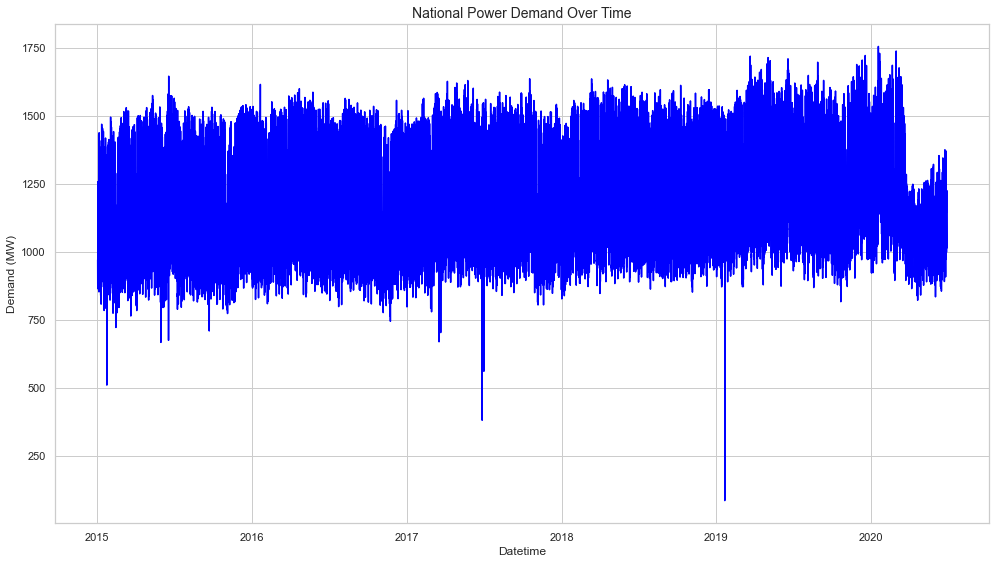

In [126]:
#National Power Demand Over Time

plt.figure(figsize=(14, 8))
plt.plot(df['datetime'], df['nat_demand'], color='blue')
plt.title('National Power Demand Over Time', fontsize=14)
plt.xlabel('Datetime')
plt.ylabel('Demand (MW)')
plt.tight_layout()
plt.show()


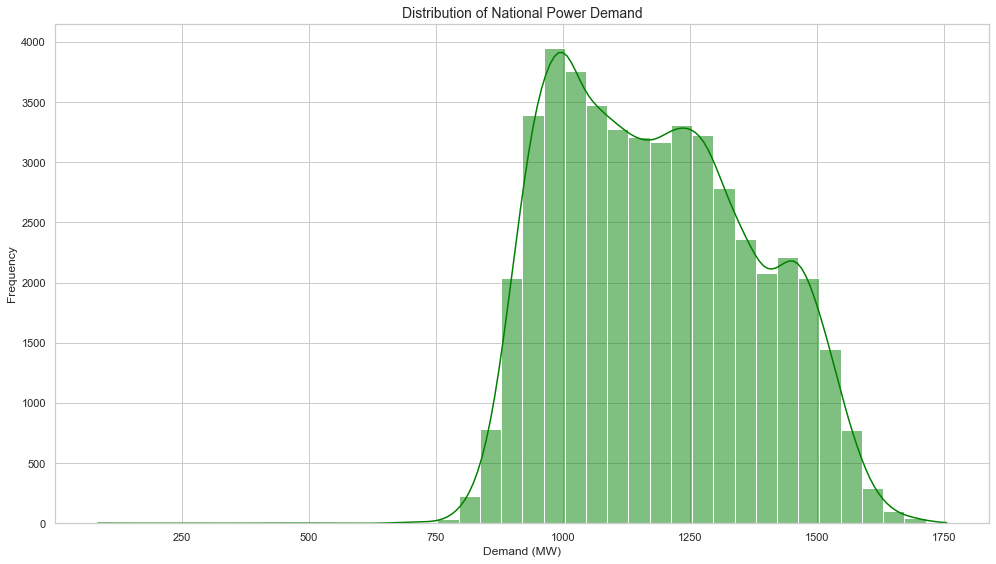

In [127]:
#Distribution of National Power Demand

plt.figure(figsize=(14, 8))
sns.histplot(df['nat_demand'], bins=40, kde=True, color='green')
plt.title('Distribution of National Power Demand', fontsize=14)
plt.xlabel('Demand (MW)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


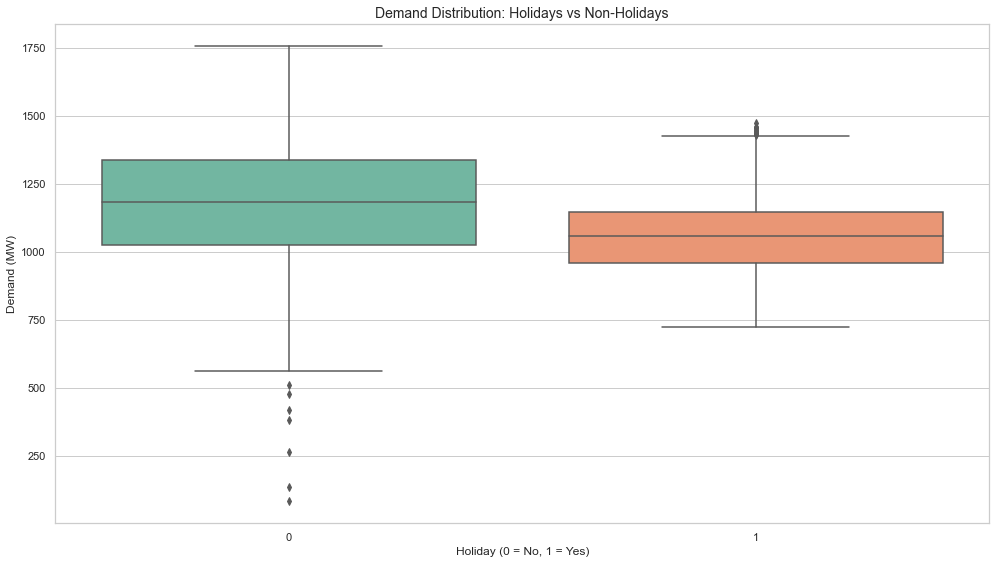

In [128]:
#Boxplot: Demand on Holidays vs Non-Holidays

plt.figure(figsize=(14, 8))
sns.boxplot(x='holiday', y='nat_demand', data=df, palette='Set2')
plt.title('Demand Distribution: Holidays vs Non-Holidays', fontsize=14)
plt.xlabel('Holiday (0 = No, 1 = Yes)')
plt.ylabel('Demand (MW)')
plt.tight_layout()
plt.show()


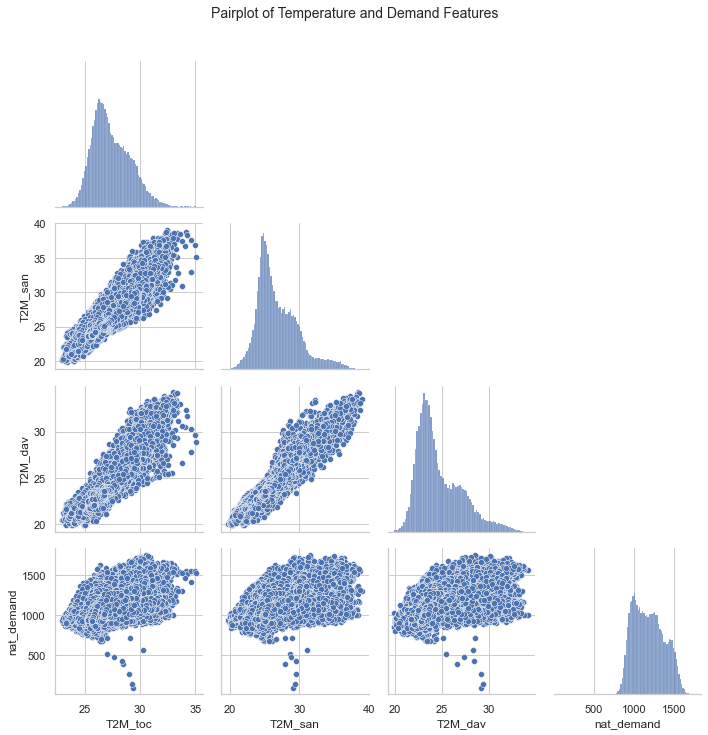

In [ ]:
#Pairplot of Selected Temperature & Demand Features

selected = ['T2M_toc', 'T2M_san', 'T2M_dav', 'nat_demand']
sns.pairplot(df[selected], height=2.5, corner=True)
plt.suptitle('Pairplot of Temperature and Demand Features', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


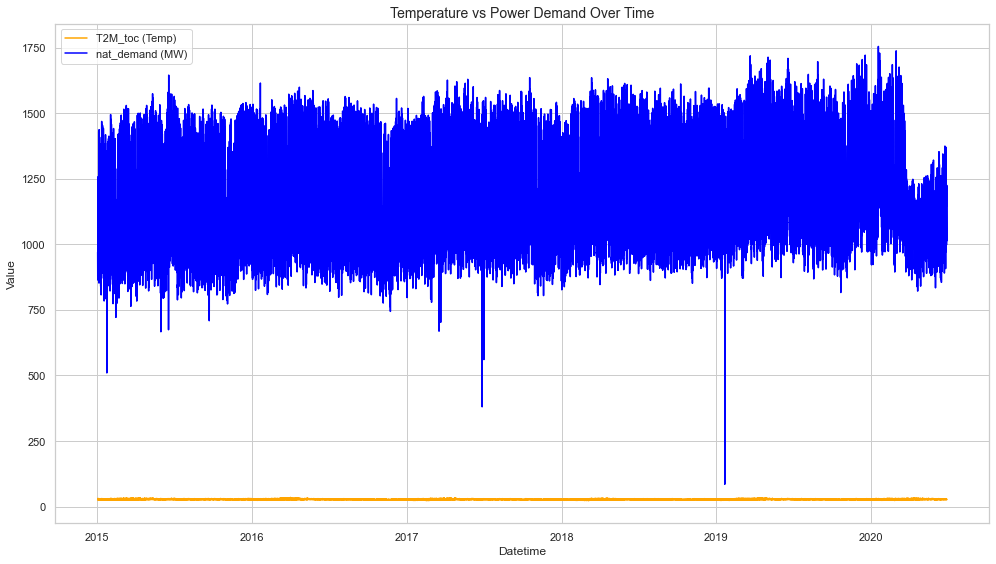

In [130]:
#Temperature vs Demand Over Time

plt.figure(figsize=(14, 8))
plt.plot(df['datetime'], df['T2M_toc'], label='T2M_toc (Temp)', color='orange')
plt.plot(df['datetime'], df['nat_demand'], label='nat_demand (MW)', color='blue')
plt.title('Temperature vs Power Demand Over Time', fontsize=14)
plt.xlabel('Datetime')
plt.ylabel('Value')
plt.legend()
plt.tight_layout()
plt.show()


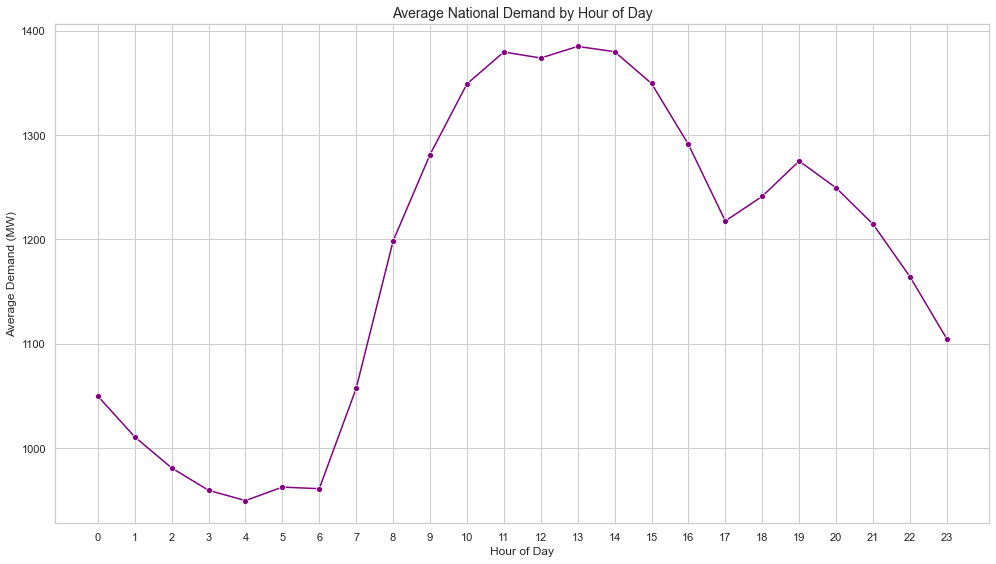

In [131]:
#Average Demand by Hour of Day

# Extract hour from datetime
df['hour'] = df['datetime'].dt.hour

plt.figure(figsize=(14, 8))
sns.lineplot(data=df, x='hour', y='nat_demand', estimator='mean', ci=None, marker='o', color='purple')
plt.title('Average National Demand by Hour of Day', fontsize=14)
plt.xlabel('Hour of Day')
plt.ylabel('Average Demand (MW)')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()


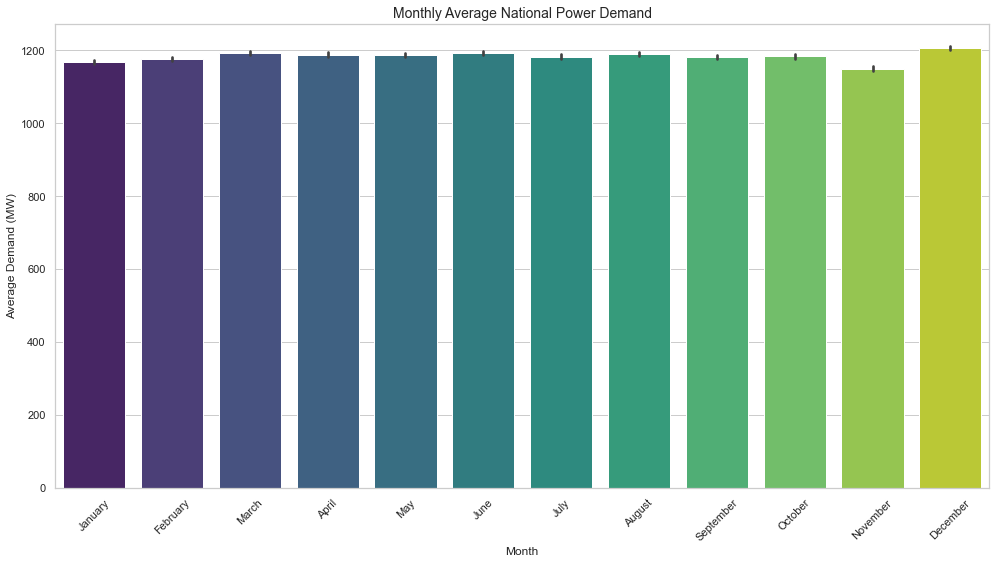

In [132]:
#Monthly Trend of Average Power Demand

# Extract month name
df['month'] = df['datetime'].dt.month_name()

# Order months correctly
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

plt.figure(figsize=(14, 8))
sns.barplot(data=df, x='month', y='nat_demand', order=month_order, palette='viridis')
plt.title('Monthly Average National Power Demand', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Average Demand (MW)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


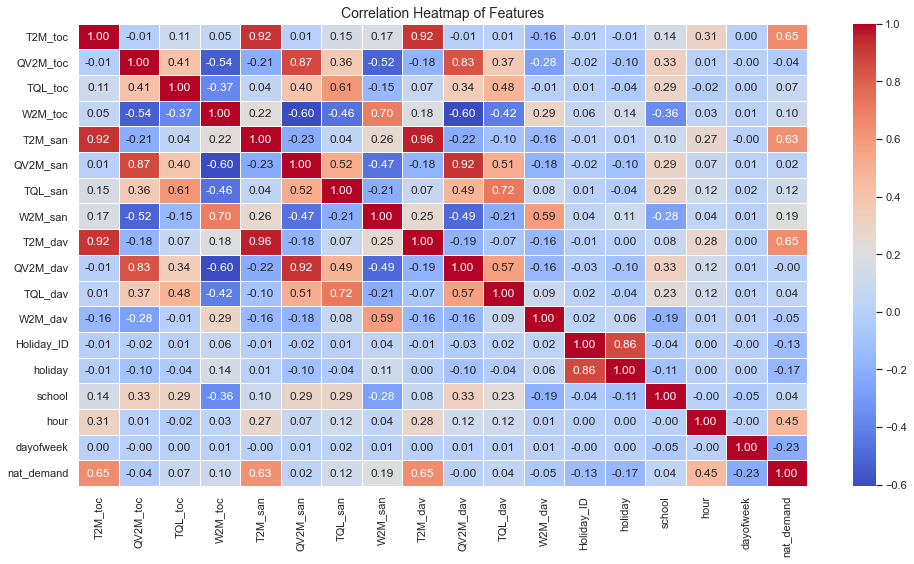

In [133]:
#Correlation Heatmap of Features

plt.figure(figsize=(14, 8))
sns.heatmap(df[features + [target]].corr(), annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Features', fontsize=14)
plt.tight_layout()
plt.show()

## 3. Normalize

In [135]:

scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()
# Ensure only numeric columns are selected
X = scaler_x.fit_transform(df[features].select_dtypes(include=[np.number]))

y = scaler_y.fit_transform(df[[target]])


## 4. Train-test split

In [136]:


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)


## 5. Dataset

In [137]:

class SimpleDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(SimpleDataset(X_train, y_train), batch_size=32, shuffle=True)
test_loader = DataLoader(SimpleDataset(X_test, y_test), batch_size=32)


## 6. Enhanced MLP model

In [138]:


class MLP(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.model(x)

## 7. Initialize

In [139]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MLP(input_size=X.shape[1]).to(device)
loss_fn = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)


## 8. Train loop

In [140]:

EPOCHS = 50
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        pred = model(X_batch).squeeze()
        loss = loss_fn(pred, y_batch.squeeze())
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    scheduler.step()
    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {total_loss/len(train_loader):.4f}")


Epoch 1/50, Loss: 0.0071
Epoch 2/50, Loss: 0.0039
Epoch 3/50, Loss: 0.0036
Epoch 4/50, Loss: 0.0034
Epoch 5/50, Loss: 0.0033
Epoch 6/50, Loss: 0.0032
Epoch 7/50, Loss: 0.0031
Epoch 8/50, Loss: 0.0030
Epoch 9/50, Loss: 0.0029
Epoch 10/50, Loss: 0.0029
Epoch 11/50, Loss: 0.0027
Epoch 12/50, Loss: 0.0027
Epoch 13/50, Loss: 0.0027
Epoch 14/50, Loss: 0.0027
Epoch 15/50, Loss: 0.0027
Epoch 16/50, Loss: 0.0026
Epoch 17/50, Loss: 0.0026
Epoch 18/50, Loss: 0.0026
Epoch 19/50, Loss: 0.0025
Epoch 20/50, Loss: 0.0025
Epoch 21/50, Loss: 0.0025
Epoch 22/50, Loss: 0.0025
Epoch 23/50, Loss: 0.0025
Epoch 24/50, Loss: 0.0025
Epoch 25/50, Loss: 0.0025
Epoch 26/50, Loss: 0.0024
Epoch 27/50, Loss: 0.0024
Epoch 28/50, Loss: 0.0024
Epoch 29/50, Loss: 0.0024
Epoch 30/50, Loss: 0.0024
Epoch 31/50, Loss: 0.0024
Epoch 32/50, Loss: 0.0024
Epoch 33/50, Loss: 0.0024
Epoch 34/50, Loss: 0.0024
Epoch 35/50, Loss: 0.0024
Epoch 36/50, Loss: 0.0024
Epoch 37/50, Loss: 0.0024
Epoch 38/50, Loss: 0.0024
Epoch 39/50, Loss: 0.

## 9. Evaluation

In [142]:

model.eval()
preds, actuals = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        pred = model(X_batch).cpu().numpy()
        preds.extend(pred)
        actuals.extend(y_batch.numpy())

## 10. Inverse transform

In [144]:

preds = scaler_y.inverse_transform(np.array(preds))
actuals = scaler_y.inverse_transform(np.array(actuals))


## 11. Metrics

In [145]:

mape = mean_absolute_percentage_error(actuals, preds)
rmse = mean_squared_error(actuals, preds, squared=False)
r2 = r2_score(actuals, preds)
print(f"\n📊 MAPE: {mape*100:.2f}%")
print(f"📉 RMSE: {rmse:.2f}")
print(f"📈 R² Score: {r2:.4f}")



📊 MAPE: 4.81%
📉 RMSE: 72.71
📈 R² Score: 0.8568


## 12. Plot

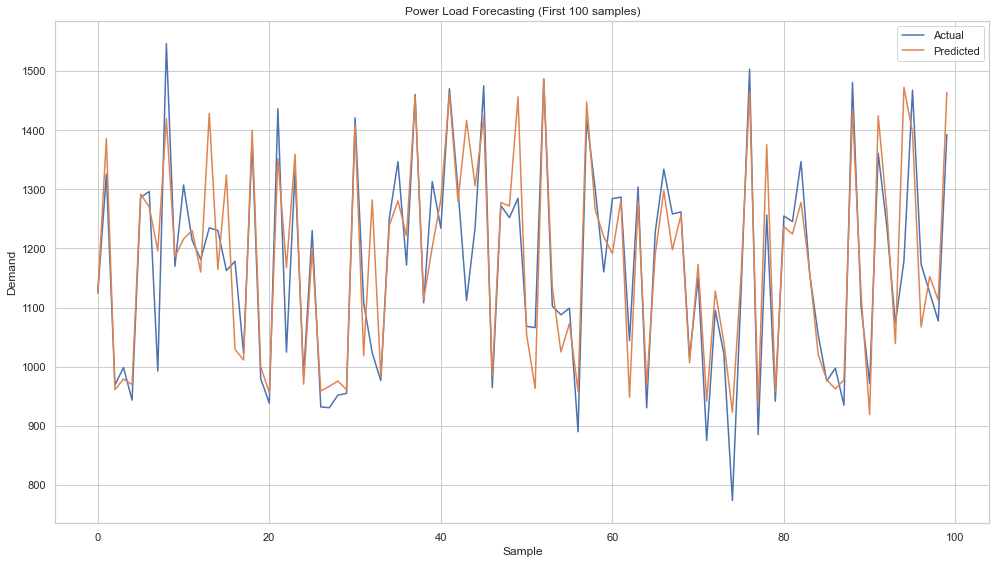

In [152]:
plt.figure(figsize=(14,8))
plt.plot(actuals[:100], label='Actual')
plt.plot(preds[:100], label='Predicted')
plt.title("Power Load Forecasting (First 100 samples)")
plt.xlabel("Sample")
plt.ylabel("Demand")
plt.legend()
plt.tight_layout()
plt.show()


## Save model and scalers

In [147]:

torch.save(model.state_dict(), "mlp_powerload_model.pt")
import joblib
joblib.dump(scaler_x, "scaler_x.save")
joblib.dump(scaler_y, "scaler_y.save")


['scaler_y.save']

# Manual Checking

In [1]:
# Load everything
import joblib
import torch
import numpy as np
from torch import nn

# Same model architecture
class MLP(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.model(x)

# Load scalers
scaler_x = joblib.load("scaler_x.save")
scaler_y = joblib.load("scaler_y.save")

# Load model
model = MLP(input_size=18)
model.load_state_dict(torch.load("mlp_powerload_model.pt", map_location=torch.device('cpu')))
model.eval()


c:\Users\PythonTeam\anaconda3\envs\python39\lib\site-packages\torch\_subclasses\functional_tensor.py:276: UserWarning: Failed to initialize NumPy: DLL load failed while importing _multiarray_umath: The specified module could not be found. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:81.)
  cpu = _conversion_method_template(device=torch.device("cpu"))


ImportError: DLL load failed while importing _multiarray_umath: The specified module could not be found.

ImportError: numpy._core.multiarray failed to import

In [33]:
# Input 18 features as string
raw_input = input("Enter 18 values (comma separated):\n").strip()

# Convert to numpy array
features = np.array([float(x) for x in raw_input.split(',')], dtype=np.float32).reshape(1, -1)

# Scale input and predict
X_scaled = scaler_x.transform(features)
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
with torch.no_grad():
    y_pred = model(X_tensor).numpy()

# Inverse transform
predicted_load = scaler_y.inverse_transform(y_pred)
print(f"\n🔮 Predicted Power Load: {predicted_load[0][0]:.2f}")


Enter 18 values (comma separated):
 25.86525879, 0.018576382, 0.016174316, 21.85054582,23.48244629, 0.017271755, 0.001855373, 10.32894873,22.66213379, 0.016562222, 0.09609985,5.364147952,0,0,0,1,3,1



🔮 Predicted Power Load: 1045.16


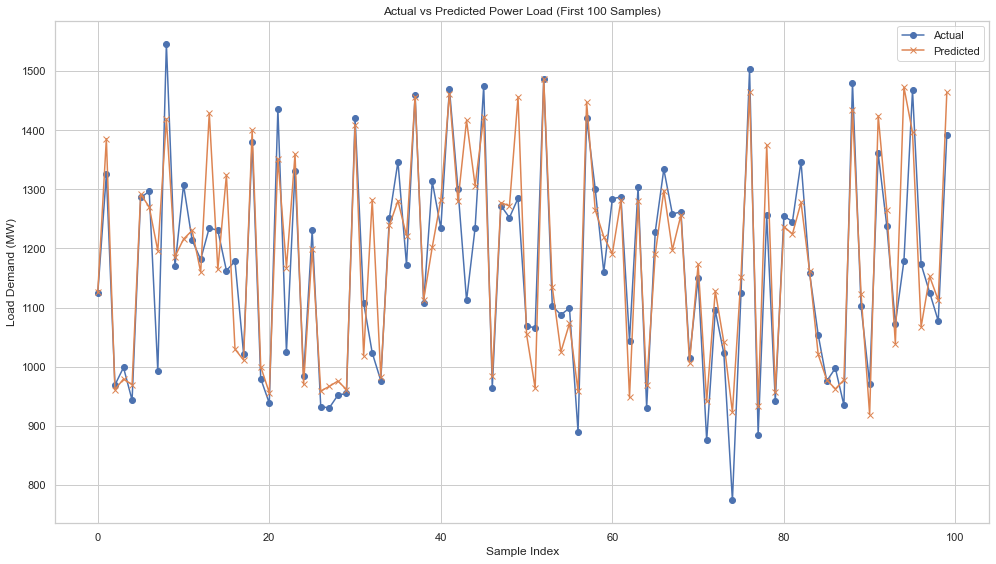

In [153]:
#Shows how close the model’s predictions are to the actual values.

plt.figure(figsize=(14, 8))
plt.plot(actuals[:100], label='Actual', marker='o')
plt.plot(preds[:100], label='Predicted', marker='x')
plt.title('Actual vs Predicted Power Load (First 100 Samples)')
plt.xlabel('Sample Index')
plt.ylabel('Load Demand (MW)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


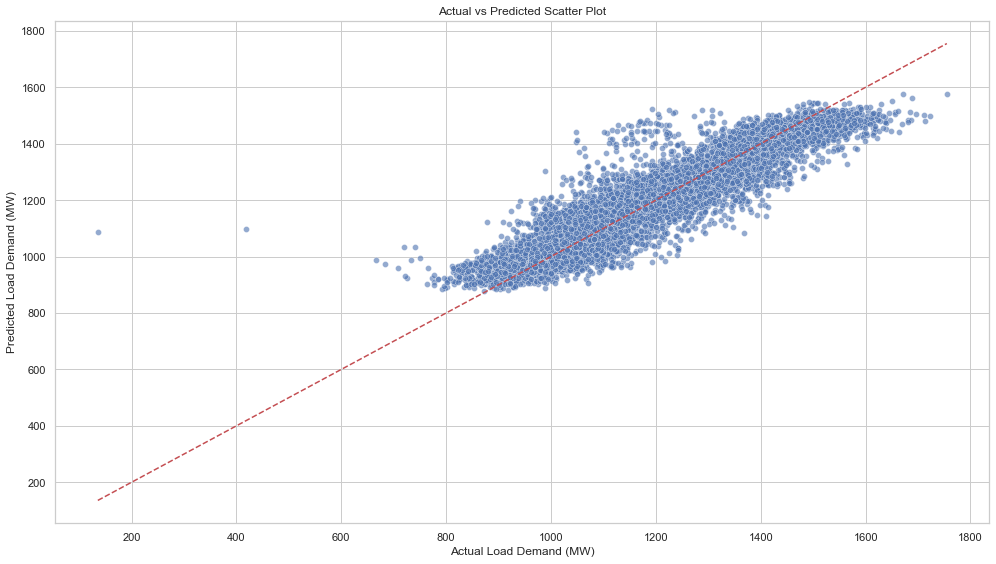

In [154]:
# Visualize overall correlation between actual and predicted values.

plt.figure(figsize=(14, 8))
sns.scatterplot(x=actuals.flatten(), y=preds.flatten(), alpha=0.6)
plt.plot([actuals.min(), actuals.max()], [actuals.min(), actuals.max()], 'r--')
plt.xlabel("Actual Load Demand (MW)")
plt.ylabel("Predicted Load Demand (MW)")
plt.title("Actual vs Predicted Scatter Plot")
plt.grid(True)
plt.tight_layout()
plt.show()


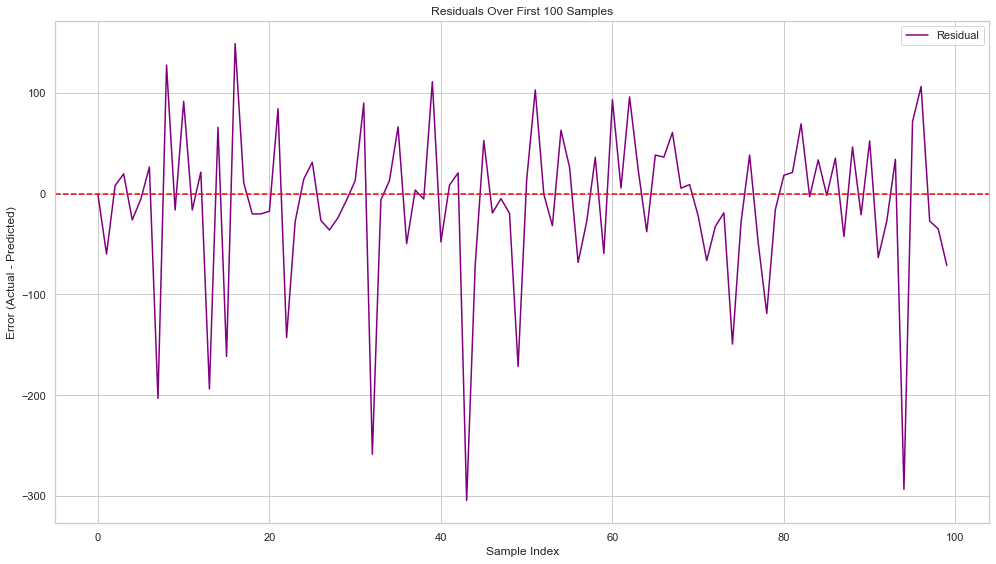

In [155]:
#Checks for bias or patterns in prediction errors (residuals).

residuals = actuals.flatten() - preds.flatten()

plt.figure(figsize=(14, 8))
plt.plot(residuals[:100], label='Residual', color='purple')
plt.axhline(0, linestyle='--', color='red')
plt.title("Residuals Over First 100 Samples")
plt.xlabel("Sample Index")
plt.ylabel("Error (Actual - Predicted)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


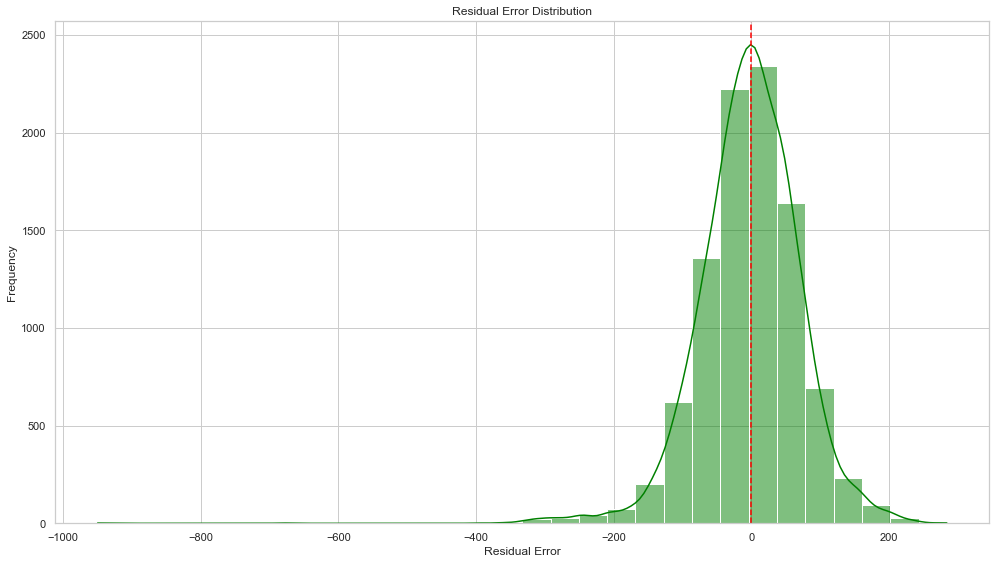

In [156]:
#Shows distribution of prediction errors.

plt.figure(figsize=(14, 8))
sns.histplot(residuals, kde=True, color='green', bins=30)
plt.axvline(0, color='red', linestyle='--')
plt.title("Residual Error Distribution")
plt.xlabel("Residual Error")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()
